In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
X, y = make_classification(
    n_samples=300,
    n_features=2,          # 2D for visualization
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [5]:
nb = GaussianNB()
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [6]:
y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)   # Probabilities (important!)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.92

Confusion Matrix:
 [[36  4]
 [ 2 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.90      0.92        40
           1       0.89      0.94      0.92        35

    accuracy                           0.92        75
   macro avg       0.92      0.92      0.92        75
weighted avg       0.92      0.92      0.92        75



In [8]:
print("Class means:\n", nb.theta_)   # μ (mean for each feature per class)
print("Class variances:\n", nb.var_) # σ² (variance for each feature per class)


Class means:
 [[-0.99989198 -0.02411298]
 [ 0.93313244  0.01790119]]
Class variances:
 [[0.45589483 1.36631605]
 [0.44373078 1.53615763]]


In [9]:
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

In [10]:
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

In [11]:
Z = nb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

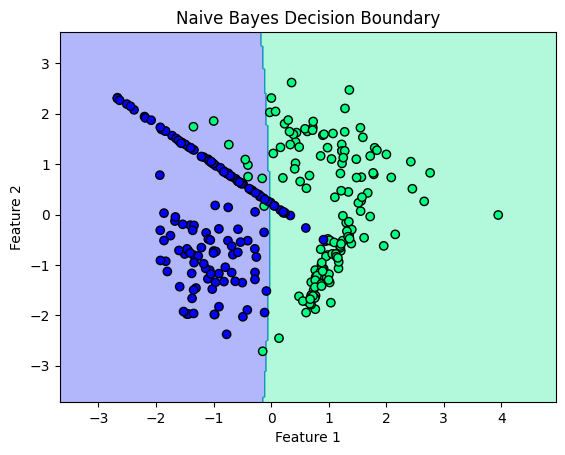

In [12]:
plt.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', edgecolor='k')
plt.title("Naive Bayes Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()